# TP2 - Doublons et Standardisation

**Difficulté:** Débutant  
**Dataset:** customers_duplicates.csv  
**Description:** Détection et suppression des doublons, standardisation des formats

---


## Imports des Bibliothèques


In [294]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [295]:
# Charger le dataset
df = pd.read_csv('customers_duplicates.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 12 lignes × 5 colonnes
Taille mémoire: 0.00 MB




,name,email,phone,gender,country
0,Bob Dubois,ALICE.MARTIN@GMAIL.COM,+33623456789,Male,Belgique
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   name     12 non-null     object
 1   email    12 non-null     object
 2   phone    12 non-null     object
 3   gender   12 non-null     object
 4   country  12 non-null     object
dtypes: object(5)
memory usage: 612.0+ bytes


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

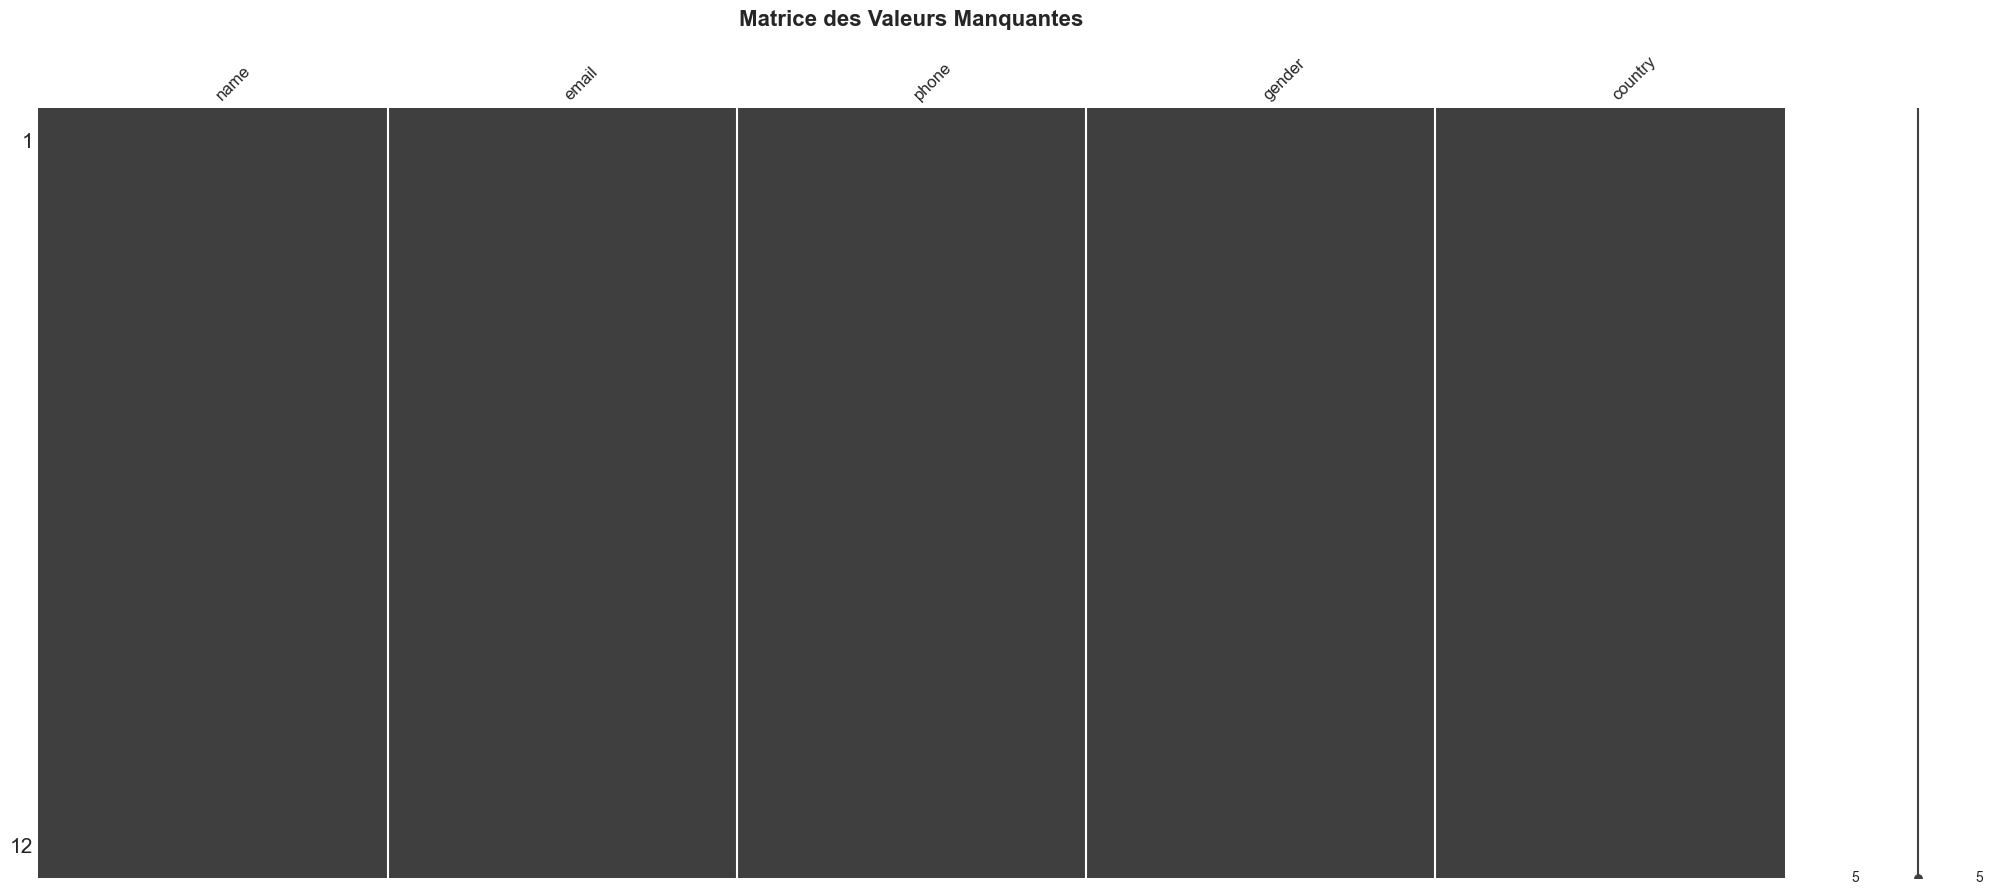


 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [296]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Combien de doublons exacts le dataset contient-il ?
2. Quelles colonnes peuvent servir de clés pour identifier les doublons ?
3. Y a-t-il des variations d'écriture dans les catégories (ex: 'M'/'Male') ?
4. Combien de formats de téléphone différents sont présents ?
5. Les emails sont-ils tous en minuscules ?
6. Y a-t-il des espaces en début ou fin de chaînes ?
7. Combien de clients uniques après déduplication ?
8. Quelle est la variation la plus fréquente du genre ?
9. Y a-t-il des doublons partiels (même nom mais email différent) ?
10. Quel pourcentage du dataset est constitué de doublons ?


In [297]:
# 1. Combien de doublons exacts le dataset contient-il ?

duplicates = df.duplicated()
print(f"Nombre de doublons: {duplicates.sum()}")

Nombre de doublons: 4


In [298]:
# 2. Quelles colonnes peuvent servir de clés pour identifier les doublons ?

# name, email et phone

df[df.duplicated(keep=False)]

,name,email,phone,gender,country
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
7,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
10,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
11,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France


In [299]:
# 3. Y a-t-il des variations d'écriture dans les catégories (ex: 'M'/'Male') ?

df['gender'].value_counts()

gender
Female    6
Male      5
F         1
Name: count, dtype: int64

In [300]:
# 4. Combien de formats de téléphone différents sont présents ?

df['phone'].value_counts()

# 2 formats

phone
+33645678901         3
+33612345678         3
+33634567890         3
+33623456789         2
+33 6 12 34 56 78    1
Name: count, dtype: int64

In [301]:
# 5. Les emails sont-ils tous en minuscules ?

df['email'].value_counts()

email
david.bernard@company.com    3
alice.martin@gmail.com       3
claire.petit@outlook.com     3
bob.dubois@yahoo.fr          2
ALICE.MARTIN@GMAIL.COM       1
Name: count, dtype: int64

In [302]:
# 6. Y a-t-il des espaces en début ou fin de chaînes ?

df['email'].str.contains(' ')


0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
Name: email, dtype: bool

In [303]:
# 7. Combien de clients uniques après déduplication ?

df['name'].unique()

# 4 clients uniques

array(['Bob Dubois', 'alice martin', 'David Bernard', 'Claire Petit',
       'Alice Martin'], dtype=object)

In [304]:
# 8. Quelle est la variation la plus fréquente du genre ?

df['gender'].value_counts()

gender
Female    6
Male      5
F         1
Name: count, dtype: int64

In [305]:
# 9. Y a-t-il des doublons partiels (même nom mais email différent) ?

# Oui

df

,name,email,phone,gender,country
0,Bob Dubois,ALICE.MARTIN@GMAIL.COM,+33623456789,Male,Belgique
1,alice martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33 6 12 34 56 78,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,F,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,FR
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
7,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


In [306]:
# 10. Quel pourcentage du dataset est constitué de doublons ?

pourcentage_doublons = (duplicates.sum()) * 100 / df.shape[0]
pourcentage_doublons


np.float64(33.333333333333336)

## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Identifier et compter les doublons exacts
### Étape 2: Afficher quelques exemples de doublons
### Étape 3: Supprimer les doublons exacts en gardant la première occurrence
### Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
### Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
### Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
### Étape 7: Appliquer le mapping aux colonnes concernées
### Étape 8: Standardiser les formats de téléphone
### Étape 9: Vérifier les doublons restants après standardisation
### Étape 10: Créer un rapport de nettoyage avec les statistiques


In [307]:
# ========================================
# Étape 1: Identifier et compter les doublons exacts
# ========================================

# TODO: Écrivez votre code ici

duplicates = df.duplicated()
print(f"Nombre de doublons: {duplicates.sum()}")

# Vérification
print(f" Étape 1 complétée")

Nombre de doublons: 4
 Étape 1 complétée


In [308]:
# ========================================
# Étape 2: Afficher quelques exemples de doublons
# ========================================

# TODO: Écrivez votre code ici

df[df.duplicated(keep=False)]

,name,email,phone,gender,country
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
7,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
9,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
10,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
11,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France


In [309]:
# Vérification
print(f" Étape 2 complétée")

 Étape 2 complétée


In [310]:
# ========================================
# Étape 3: Supprimer les doublons exacts en gardant la première occurrence
# ========================================

# TODO: Écrivez votre code ici

df = df.drop_duplicates(keep='first')

# Vérification
print(f" Étape 3 complétée")

 Étape 3 complétée


In [311]:
# ========================================
# Étape 4: Standardiser la casse (emails en minuscules, noms en title case)
# ========================================

# TODO: Écrivez votre code ici

# Standardisation de la casse et des espaces (emails en miniscule)
def clean_text_email(text):
    if pd.isna(text):
        return text

    text = str(text)                        # convertit en str
    text = text.strip()                     # supprime les espaces début/fin
    text = text.lower()
    text = ' '.join(text.split())           # supprime les espaces multiples entre les mots

    # Standardiser la casse (selon le contexte)
    # text = text.lower()   # Pour les emails, identifiants
    # text = text.title()   # Pour les noms propres
    # text = text.upper()   # Pour les codes

    return text

# Application sur la colonne email
df['email'] = df['email'].apply(clean_text_email)

In [312]:
# Standardisation de la casse et des espaces (nom en title case)
def clean_text_name(text):
    if pd.isna(text):
        return text

    text = str(text)                            # convertit en str
    text = text.strip()                         # supprime les espaces début/fin
    text = text.title()
    text = ' '.join(text.split())               # supprime les espaces multiples entre les mots

    # Standardiser la casse (selon le contexte)
    # text = text.lower()   # Pour les emails, identifiants
    # text = text.title()   # Pour les noms propres
    # text = text.upper()   # Pour les codes

    return text

# Application sur la colonne name
df['name'] = df['name'].apply(clean_text_name)

In [313]:
# Vérification
print(f" Étape 4 complétée")

 Étape 4 complétée


In [314]:
# ========================================
# Étape 5: Supprimer les espaces en début/fin de toutes les colonnes texte
# ========================================

# TODO: Écrivez votre code ici

def clean_text_text(text):
    if pd.isna(text):
        return text

    text = str(text)                        # convertit en str
    text = text.strip()                     # supprime les espaces début/fin
    text = ' '.join(text.split())           # supprime les espaces multiples entre les mots

    # Standardiser la casse (selon le contexte)
    # text = text.lower()   # Pour les emails, identifiants
    # text = text.title()   # Pour les noms propres
    # text = text.upper()   # Pour les codes

    return text

# Application sur les colonnes textuelles
text_columns = df.select_dtypes(include=['object']).columns
for col in text_columns:
    df[col] = df[col].apply(clean_text_text)


In [315]:
# Vérification
print(f" Étape 5 complétée")

 Étape 5 complétée


In [316]:
# ========================================
# Étape 6: Créer un mapping pour standardiser les catégories (genre, pays)
# ========================================

# TODO: Écrivez votre code ici

# Mapping des variations vers une valeur standard

category_mapping = {
    # Genre
    'M': 'Male', 'H': 'Male', 'Homme': 'Male', 'homme': 'Male',
    'F': 'Female', 'Femme': 'Female', 'femme': 'Female',
    # Pays
    'USA': 'United States', 'US': 'United States', 'Etats-Unis': 'United States',
    'UK': 'United Kingdom', 'GB': 'United Kingdom', 'FR' : 'France',
}

# Vérification
print(f" Étape 6 complétée")

 Étape 6 complétée


In [317]:
# ========================================
# Étape 7: Appliquer le mapping aux colonnes concernées
# ========================================

# TODO: Écrivez votre code ici

# Application du mapping
for col in ['gender', 'country']:
    if col in df.columns:
        df[col] = df[col].map(lambda x: category_mapping.get(x, x))

# Vérification
print(f" Étape 7 complétée")

 Étape 7 complétée


In [318]:
# ========================================
# Étape 8: Standardiser les formats de téléphone
# ========================================

# TODO: Écrivez votre code ici

import re

def standardize_phone(phone):
    """Standardise les numéros de téléphone au format international"""
    if pd.isna(phone):
        return None


    # Retirer tous les caractères non numériques
    phone = re.sub(r'\D', '', str(phone))
    
    # Format français
    if len(phone) == 10 and phone.startswith('0'):
        return f"+33{phone[1:]}"
    elif len(phone) == 9:  # Sans le 0 initial
        return f"+33{phone}"
    elif len(phone) == 11 and phone.startswith('33'):
        return f"+{phone}"

    return phone

df['phone'] = df['phone'].apply(standardize_phone)

In [319]:
# Vérification
print(f" Étape 8 complétée")

 Étape 8 complétée


In [320]:
# ========================================
# Étape 9: Vérifier les doublons restants après standardisation
# ========================================

# TODO: Écrivez votre code ici

df[df.duplicated(keep=False)]

,name,email,phone,gender,country
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
8,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France


In [321]:
df = df.drop_duplicates(keep='first')

In [322]:
df[df.duplicated(keep=False)]

,name,email,phone,gender,country


In [323]:
# Vérification
print(f" Étape 9 complétée")

 Étape 9 complétée


In [324]:
df

,name,email,phone,gender,country
0,Bob Dubois,alice.martin@gmail.com,+33623456789,Male,Belgique
1,Alice Martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33612345678,Male,Belgique
3,David Bernard,david.bernard@company.com,+33645678901,Female,Suisse
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse


In [325]:
# On apperçoit des doublons partiels

df_sorted = df.sort_values(by=["name"], ascending=True)
df_sorted

,name,email,phone,gender,country
1,Alice Martin,bob.dubois@yahoo.fr,+33623456789,Male,Belgique
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
0,Bob Dubois,alice.martin@gmail.com,+33623456789,Male,Belgique
2,Bob Dubois,bob.dubois@yahoo.fr,+33612345678,Male,Belgique
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
3,David Bernard,david.bernard@company.com,+33645678901,Female,Suisse
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse


In [326]:
df_clean = df_sorted.drop_duplicates(subset=["name"], keep="last")
df_clean

,name,email,phone,gender,country
5,Alice Martin,alice.martin@gmail.com,+33612345678,Female,France
2,Bob Dubois,bob.dubois@yahoo.fr,+33612345678,Male,Belgique
4,Claire Petit,claire.petit@outlook.com,+33634567890,Female,France
6,David Bernard,david.bernard@company.com,+33645678901,Male,Suisse


In [327]:
# ========================================
# Étape 10: Créer un rapport de nettoyage avec les statistiques
# ========================================

# TODO: Écrivez votre code ici





# Vérification
print(f" Étape 10 complétée")

 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [328]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': ((12, 5)),
    'Dimensions_finales': df_clean.shape, 
    'Lignes_supprimées': 8,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 8,
    'Outliers_traités': 0,
    'Transformations_appliquées': ["Suppression des doublons. Standardisation des emails, téléphones, gendre et pays."]
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n 🎉 TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (12, 5)
Dimensions_finales...................... (4, 5)
Lignes_supprimées....................... 8
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 8
Outliers_traités........................ 0
Transformations_appliquées.............. ['Suppression des doublons. Standardisation des emails, téléphones, gendre et pays.']

 🎉 TP terminé avec succès!
